In [3]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import random
import time
from faker import Faker

fake = Faker()

file_name = "live_fraud_stream.csv"

# Create CSV with headers first
columns = [
    "transaction_id",
    "timestamp",
    "amount",
    "merchant_category",
    "device_type",
    "is_international",
    "previous_fraud_count",
    "card_age_months",
    "is_fraud"
]

df = pd.DataFrame(columns=columns)
df.to_csv(file_name, index=False)

transaction_id = 1

print("Starting Live Transaction Feed...\n")

while transaction_id <= 300:

    # Fraud probability ~7%
    is_fraud = np.random.choice([0,1], p=[0.93,0.07])

    # Fraud transactions slightly higher amount
    if is_fraud == 1:
        amount = round(np.random.uniform(1000, 5000),2)
    else:
        amount = round(np.random.exponential(scale=200),2)

    new_data = {
        "transaction_id": transaction_id,
        "timestamp": fake.date_time_this_year().isoformat(),
        "amount": amount,
        "merchant_category": random.choice(["electronics","grocery","travel","fuel","fashion"]),
        "device_type": random.choice(["mobile","web"]),
        "is_international": random.choice(["yes","no"]),
        "previous_fraud_count": np.random.randint(0,5),
        "card_age_months": np.random.randint(1,60),
        "is_fraud": is_fraud
    }

    pd.DataFrame([new_data]).to_csv(file_name, mode='a', header=False, index=False)

    print(f"Added Transaction {transaction_id}")

    transaction_id += 1
    time.sleep(1)  # 1 second delay to simulate live feed

print("\nData Generation Completed Successfully.")

First 5 rows:
   transaction_id                   timestamp  amount merchant_category  \
0               1  2026-02-04T14:32:02.980898  150.41              fuel   
1               2  2026-02-10T07:28:32.878998  341.80           grocery   
2               3  2026-01-09T18:43:01.463684   83.73              fuel   
3               4  2026-02-10T19:36:57.642380  149.02           fashion   
4               5  2026-02-27T06:26:01.505893  297.86           grocery   

  device_type is_international  previous_fraud_count  card_age_months  \
0         web              yes                     0               18   
1         web              yes                     2               40   
2      mobile               no                     4               36   
3      mobile               no                     3               18   
4      mobile              yes                     0               39   

   is_fraud  
0         0  
1         0  
2         0  
3         0  
4         0  

Dataset Inf

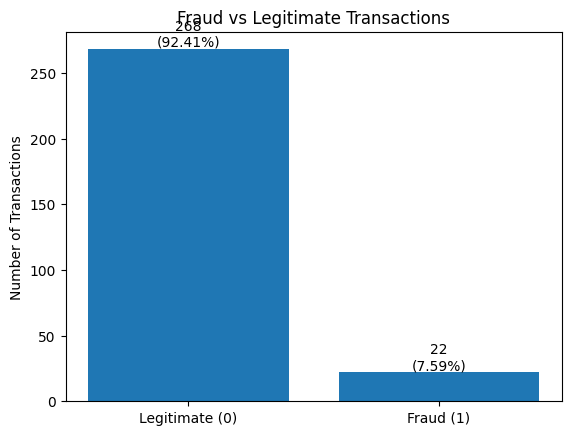

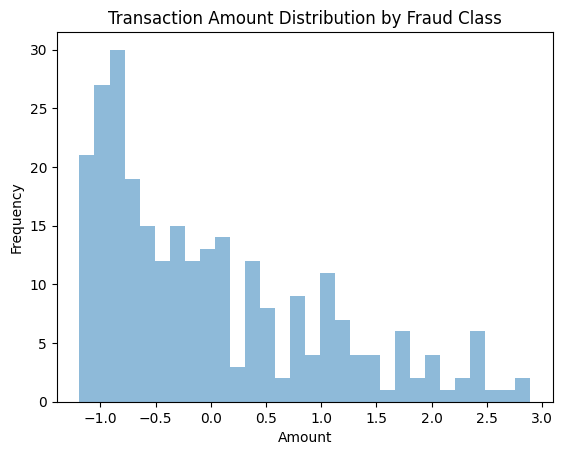

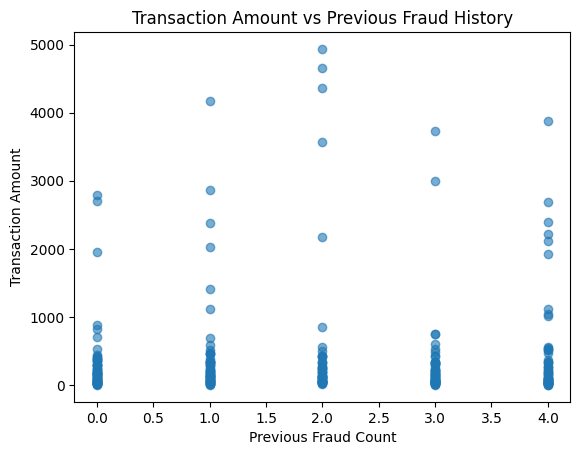

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/live_fraud_stream.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# Check Missing Values & Duplicates
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Fraud Distribution
print("\nFraud Distribution:")
print(df['is_fraud'].value_counts())

# Handle Missing Values (if any)
df.fillna(df.median(numeric_only=True), inplace=True)

# Separate legit and fraud
legit = df[df['is_fraud'] == 0]
fraud = df[df['is_fraud'] == 1]

Q1 = legit['amount'].quantile(0.25)
Q3 = legit['amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

legit = legit[(legit['amount'] >= lower) & (legit['amount'] <= upper)]

df = pd.concat([legit, fraud])

print(df['is_fraud'].value_counts())

df = df[(df['amount'] >= lower) & (df['amount'] <= upper)]

# Encode Categorical Variables
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Feature Scaling
scaler = StandardScaler()

numerical_cols = df.drop('is_fraud', axis=1).select_dtypes(include=np.number).columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Visualization

# Fraud vs Legitimate transactions
plt.figure()
plt.bar(['Legitimate (0)', 'Fraud (1)'], [268, 22])
plt.title("Fraud vs Legitimate Transactions")
plt.ylabel("Number of Transactions")
plt.text(0, 268, "268\n(92.41%)", ha='center', va='bottom')
plt.text(1, 22, "22\n(7.59%)", ha='center', va='bottom')

plt.show()

# Transaction Amount Distribution
plt.figure()
plt.hist(df[df['is_fraud']==0]['amount'], bins=30, alpha=0.5)
plt.hist(df[df['is_fraud']==1]['amount'], bins=30, alpha=0.5)
plt.title("Transaction Amount Distribution by Fraud Class")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Scatter Plot
df_vis = pd.read_csv("live_fraud_stream.csv")
plt.figure()

plt.scatter(
    df_vis['previous_fraud_count'],
    df_vis['amount'],
    alpha=0.6
)
plt.xlabel("Previous Fraud Count")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount vs Previous Fraud History")
plt.show()


Columns in dataset: Index(['transaction_id', 'timestamp', 'amount', 'merchant_category',
       'device_type', 'is_international', 'previous_fraud_count',
       'card_age_months', 'is_fraud'],
      dtype='object')

Model Performance Comparison:

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.977778   1.000000  0.714286  0.833333
Decision Tree        0.977778   0.777778  1.000000  0.875000
Random Forest        0.988889   1.000000  0.857143  0.923077


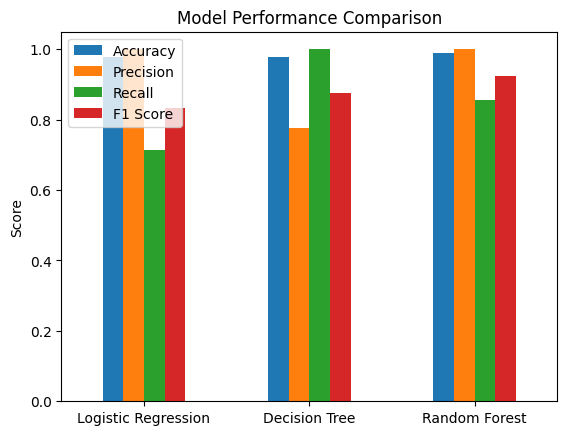

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

df = pd.read_csv("/content/cleaned_fraud_data.csv")


print("Columns in dataset:", df.columns)

timestamp_cols = [col for col in df.columns if "time" in col.lower()]
for col in timestamp_cols:
    df[col] = pd.to_datetime(df[col])
    df[col + "_hour"] = df[col].dt.hour
    df[col + "_day"] = df[col].dt.day
    df[col + "_month"] = df[col].dt.month
    df.drop(col, axis=1, inplace=True)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'is_fraud']  # exclude target
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

results = {}

# Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr)
}

# Decision Tree

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

results["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1 Score": f1_score(y_test, y_pred_dt)
}

# Random Forest

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
}

results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:\n")
print(results_df)

results_df.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()